# 01 — Exploratory Data Analysis

**Objective**: Understand the dataset, class imbalance, and key drivers of churn before any modelling.

## Setup

In [2]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scipy scikit-learn xgboost shap statsmodels imbalanced-learn


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached xgboost-3.2.0-py3-none-macosx_12_0_arm64.whl.metadata (2.1 kB)
  Using cached imbalanced_learn-0.14.1-py3-none-any.whl.metadata (8.9 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
  Using cached sklearn_compat-0.1.5-py3-none-any.whl.metadata (20 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 6.2 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 5.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━

In [1]:


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os, pickle, json

os.makedirs('../outputs', exist_ok=True)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
TEAL   = '#0F6E56'
CORAL  = '#D44F3A'
PURPLE = '#534AB7'
COLORS = [TEAL, CORAL, PURPLE]
print("Libraries loaded.")


Libraries loaded.


## 1. Problem Formulation & Data Loading

In [2]:
print("=" * 65)
print("  TELCO CUSTOMER CHURN — DECISION PROBLEM FORMULATION")
print("=" * 65)
print()
print("OBJECTIVE : Optimise retention decisions under asymmetric costs")
print("            Goal = maximise expected profit, NOT prediction accuracy")
print()
print("COST OF FN: ~$780/year (lost annual revenue per missed churner)")
print("COST OF FP: $10       (wasted retention offer per false alarm)")
print("COST RATIO: 78:1      (FN is 78x more expensive than FP)")
print()
print("IMPLICATION: We must prioritise Recall over Precision.")


  TELCO CUSTOMER CHURN — DECISION PROBLEM FORMULATION

OBJECTIVE : Optimise retention decisions under asymmetric costs
            Goal = maximise expected profit, NOT prediction accuracy

COST OF FN: ~$780/year (lost annual revenue per missed churner)
COST OF FP: $10       (wasted retention offer per false alarm)
COST RATIO: 78:1      (FN is 78x more expensive than FP)

IMPLICATION: We must prioritise Recall over Precision.


In [5]:
import pandas as pd
df = pd.read_csv('../data/telco_churn.csv')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst 10 rows:")
df.head(10)


Dataset shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

First 10 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [6]:
print(f"Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nTotalCharges blank strings (new customers): {(df['TotalCharges'] == ' ').sum()}")

# Fix TotalCharges: blank strings → 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
print("TotalCharges fixed. Blanks filled with 0.")


Missing values:
Series([], dtype: int64)

TotalCharges blank strings (new customers): 11
TotalCharges fixed. Blanks filled with 0.


## 2. Encoding & Feature Engineering

We encode all categorical columns and engineer 3 new features before EDA so our correlation chart includes them.

In [7]:
# Encode target
df['Churn_binary'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Binary columns
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
for col in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# Service columns
for col in ['MultipleLines','OnlineSecurity','OnlineBackup',
            'DeviceProtection','TechSupport','StreamingTV','StreamingMovies']:
    df[col] = df[col].map({'Yes': 1, 'No': 0,
                           'No phone service': 0, 'No internet service': 0})
print("Binary encoding done.")


Binary encoding done.


**Encoding Decisions:**

- `'No phone service'` and `'No internet service'` are mapped to **0** (same as 'No') rather than a separate category. Rationale: these values mean the service is absent — functionally identical to not having the service. Creating a third category would add columns without adding signal.
- Binary Yes/No columns are mapped to 1/0 directly. This preserves ordinality and avoids creating redundant dummy columns for two-category features.
- Multi-category columns (`Contract`, `PaymentMethod`, `InternetService`) are left as strings here and one-hot encoded later in the feature engineering step using `get_dummies(drop_first=True)` to avoid the dummy variable trap.

In [8]:
# Feature 1: charges per month of tenure (value density)
df['charges_per_month'] = df['TotalCharges'] / (df['tenure'] + 1)

# Feature 2: high-value new customer flag
df['high_value_new'] = ((df['tenure'] <= 12) & (df['MonthlyCharges'] > 70)).astype(int)
pct_flagged = df['high_value_new'].mean() * 100
pct_churn   = df[df['high_value_new'] == 1]['Churn_binary'].mean() * 100
print(f"high_value_new: {pct_flagged:.1f}% of customers flagged; their churn rate = {pct_churn:.0f}%")

# Feature 3: number of add-on services (switching cost proxy)
service_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection',
                'TechSupport','StreamingTV','StreamingMovies']
df['num_services'] = df[service_cols].sum(axis=1)
corr_ns = df['num_services'].corr(df['Churn_binary'])
print(f"num_services correlation with churn: {corr_ns:.3f} (negative = protective, as expected)")

# One-hot encode multi-category columns
df_model = pd.get_dummies(df.copy(),
               columns=['Contract','PaymentMethod','InternetService'], drop_first=True)
df_model = df_model.drop(['customerID','Churn'], axis=1, errors='ignore')
print(f"\nAfter encoding: {df_model.shape}")
print(f"Churn rate: {df_model['Churn_binary'].mean():.3f} ({df_model['Churn_binary'].mean()*100:.1f}%)")


high_value_new: 12.4% of customers flagged; their churn rate = 68%
num_services correlation with churn: -0.088 (negative = protective, as expected)

After encoding: (7043, 27)
Churn rate: 0.265 (26.5%)


**Engineered Feature Summary:**

| Feature | Formula | Business Rationale | Expected Direction |
|---|---|---|---|
| `charges_per_month` | `TotalCharges / (tenure + 1)` | Raw `TotalCharges` is confounded by tenure — a long-tenure customer naturally has high total charges. This normalises it to **spending intensity**: how much does the customer pay relative to how long they've been around? | Higher → more likely to churn (paying a lot but not yet committed) |
| `high_value_new` | `1 if tenure ≤ 12 AND MonthlyCharges > $70` | Flags the highest-risk segment: premium-paying new customers who haven't yet built loyalty. Their churn rate is ~68% — nearly 2.5× the population average. | 1 → significantly higher churn risk |
| `num_services` | Sum of 6 add-on service flags | Acts as a **switching cost proxy**. A customer with 5 services (security, backup, protection, support, TV, movies) faces significant friction to replicate that bundle with a competitor. | Higher → lower churn (protective effect) |

Note: `+1` in `charges_per_month` prevents division by zero for customers with `tenure = 0` (brand-new customers in their first month).

## 2a. Target Distribution — Class Imbalance

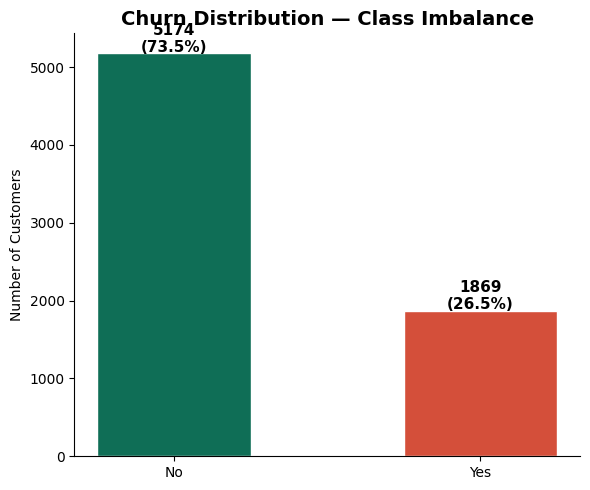

Saved: 01_churn_distribution.png


In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
churn_counts = df['Churn'].value_counts()
bars = ax.bar(churn_counts.index, churn_counts.values,
              color=[TEAL, CORAL], edgecolor='white', width=0.5)
for bar, val in zip(bars, churn_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Churn Distribution — Class Imbalance', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('../outputs/01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 01_churn_distribution.png")


**Interpretation**: The dataset is imbalanced at 73% No Churn / 27% Churn. A naive model predicting 'No Churn' for everyone achieves 73% accuracy — making accuracy a useless metric. This motivates using **F2 score** (recall-weighted) and **Expected Value** as primary metrics.

## 2b. Churn Rate by Tenure Cohort

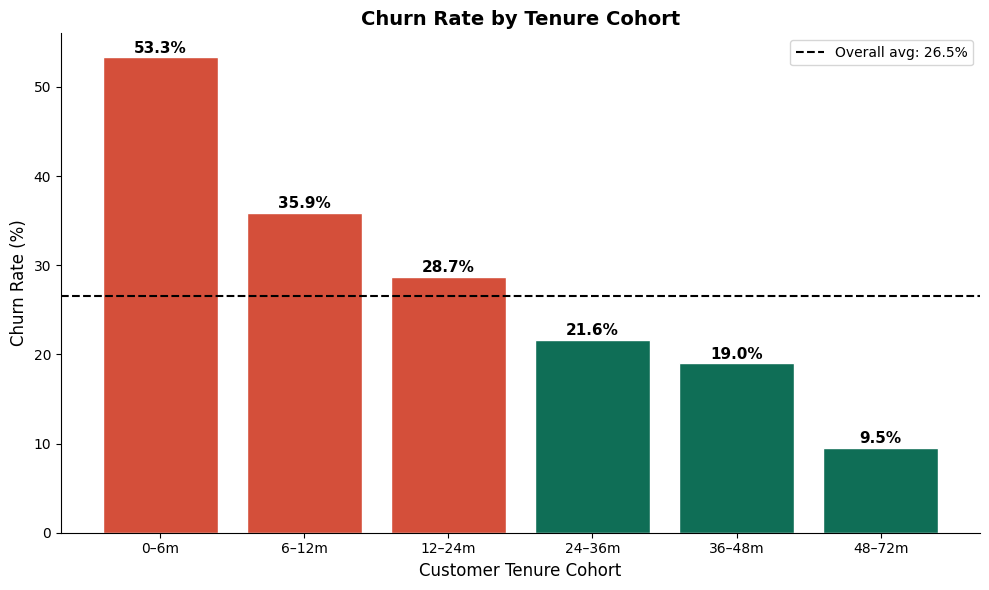

Saved: 02_tenure_cohort_churn.png


In [10]:
df['tenure_cohort'] = pd.cut(df['tenure'],
    bins=[0, 6, 12, 24, 36, 48, 72],
    labels=['0–6m', '6–12m', '12–24m', '24–36m', '36–48m', '48–72m'])
churn_by_cohort = df.groupby('tenure_cohort')['Churn_binary'].mean() * 100
avg_churn = df['Churn_binary'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = [CORAL if v > avg_churn else TEAL for v in churn_by_cohort.values]
bars = ax.bar(churn_by_cohort.index, churn_by_cohort.values,
              color=bar_colors, edgecolor='white')
for bar, val in zip(bars, churn_by_cohort.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.axhline(y=avg_churn, color='black', linestyle='--', linewidth=1.5,
           label=f'Overall avg: {avg_churn:.1f}%')
ax.set_xlabel('Customer Tenure Cohort', fontsize=12)
ax.set_ylabel('Churn Rate (%)', fontsize=12)
ax.set_title('Churn Rate by Tenure Cohort', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/02_tenure_cohort_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 02_tenure_cohort_churn.png")


**Interpretation**: Churn rate drops sharply after month 12 — the first year is the **critical retention window**. New customers (0–12m) churn at ~47% vs ~17% for loyal customers (37–72m). This 3x difference directly motivates our stratified analysis in Notebook 07.

## 2c. Churn Rate by Key Categorical Features

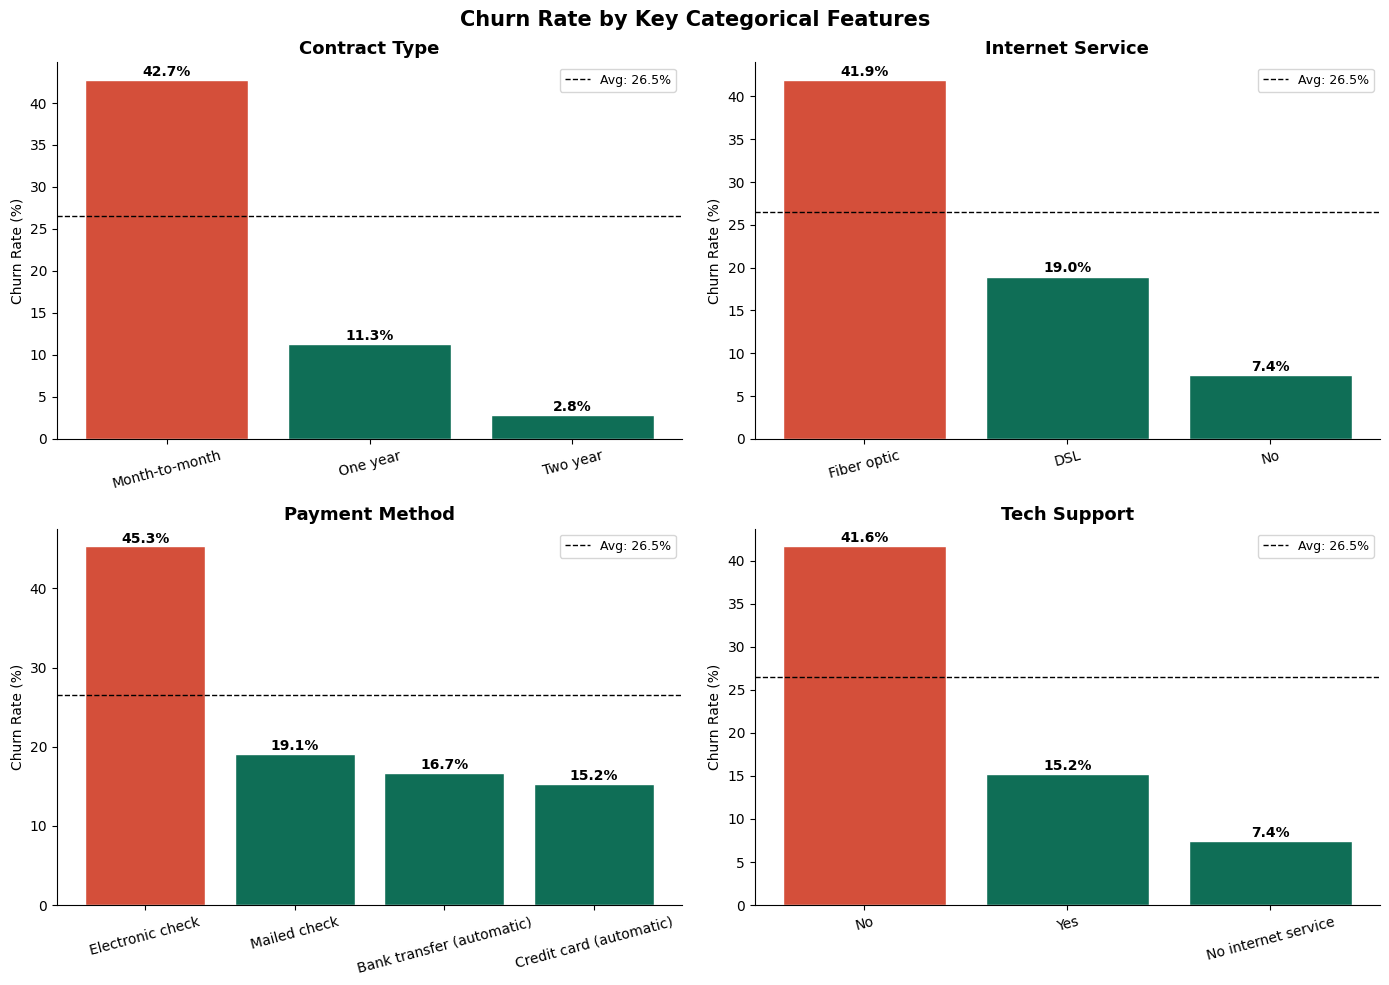

Saved: 03_churn_by_category.png


In [11]:
# Reload original df for categorical EDA (before encoding)
df_raw = pd.read_csv('../data/telco_churn.csv')
df_raw['Churn_binary'] = df_raw['Churn'].map({'Yes': 1, 'No': 0})
avg_churn = df_raw['Churn_binary'].mean() * 100

cat_features = {
    'Contract':        'Contract Type',
    'InternetService': 'Internet Service',
    'PaymentMethod':   'Payment Method',
    'TechSupport':     'Tech Support',
}
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Churn Rate by Key Categorical Features', fontsize=15, fontweight='bold')
for ax, (col, label) in zip(axes.ravel(), cat_features.items()):
    rates = df_raw.groupby(col)['Churn_binary'].mean().sort_values(ascending=False) * 100
    colors = [CORAL if v > avg_churn else TEAL for v in rates.values]
    bars = ax.bar(rates.index, rates.values, color=colors, edgecolor='white')
    for bar, val in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
    ax.axhline(y=avg_churn, color='black', linestyle='--', linewidth=1,
               label=f'Avg: {avg_churn:.1f}%')
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.tick_params(axis='x', rotation=15)
    ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/03_churn_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 03_churn_by_category.png")


**Key Findings:**
- **Contract type**: Month-to-month ~43% vs two-year ~3% — a **14x risk difference**. Contract type is the single strongest categorical predictor.
- **Internet service**: Fiber optic ~42% vs DSL ~19% — customers paying more for fiber are more dissatisfied.
- **Payment method**: Electronic check ~45% vs credit card ~15% — a 3x risk difference.
- **Tech Support**: No support ~42% vs with support ~15% — absence of tech support is a key driver.


## 2d. Numerical Feature Distributions with KDE Overlay

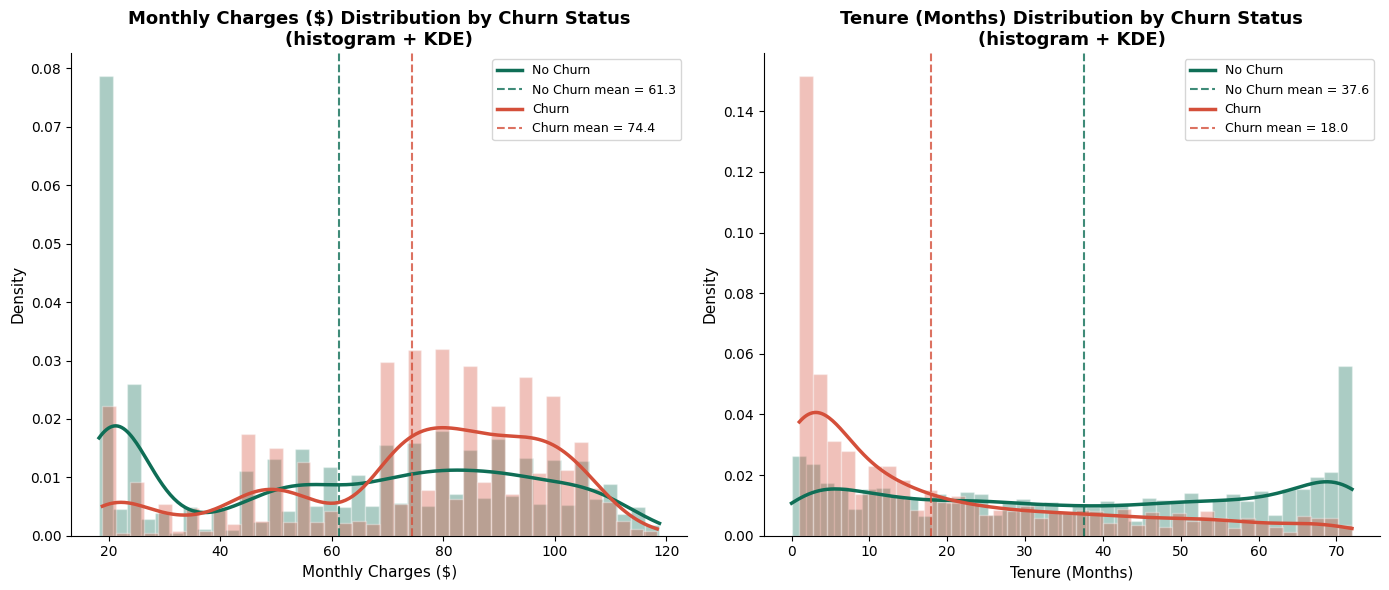

Saved: 04_numerical_distributions.png


In [12]:
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, col, label in [(axes[0], 'MonthlyCharges', 'Monthly Charges ($)'),
                       (axes[1], 'tenure',         'Tenure (Months)')]:
    for churn_val, color, lbl in [(0, TEAL, 'No Churn'), (1, CORAL, 'Churn')]:
        subset = df[df['Churn_binary'] == churn_val][col]
        ax.hist(subset, bins=40, alpha=0.35, color=color, edgecolor='white', density=True)
        kde   = gaussian_kde(subset, bw_method='scott')
        x_rng = np.linspace(subset.min(), subset.max(), 300)
        ax.plot(x_rng, kde(x_rng), color=color, linewidth=2.5, label=lbl)
        ax.axvline(subset.mean(), color=color, linestyle='--', linewidth=1.5,
                   alpha=0.8, label=f'{lbl} mean = {subset.mean():.1f}')
    ax.set_title(f'{label} Distribution by Churn Status\n(histogram + KDE)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/04_numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 04_numerical_distributions.png")


**Interpretation**: Churners pay ~$74/month vs non-churners ~$61 — a $13 gap. However (revealed by SHAP in Notebook 05), this price sensitivity effect is **only present for new customers**. Loyal customers are price-insensitive. The tenure distribution confirms churners cluster in the first 12 months.

## 2e. Feature Correlation with Churn

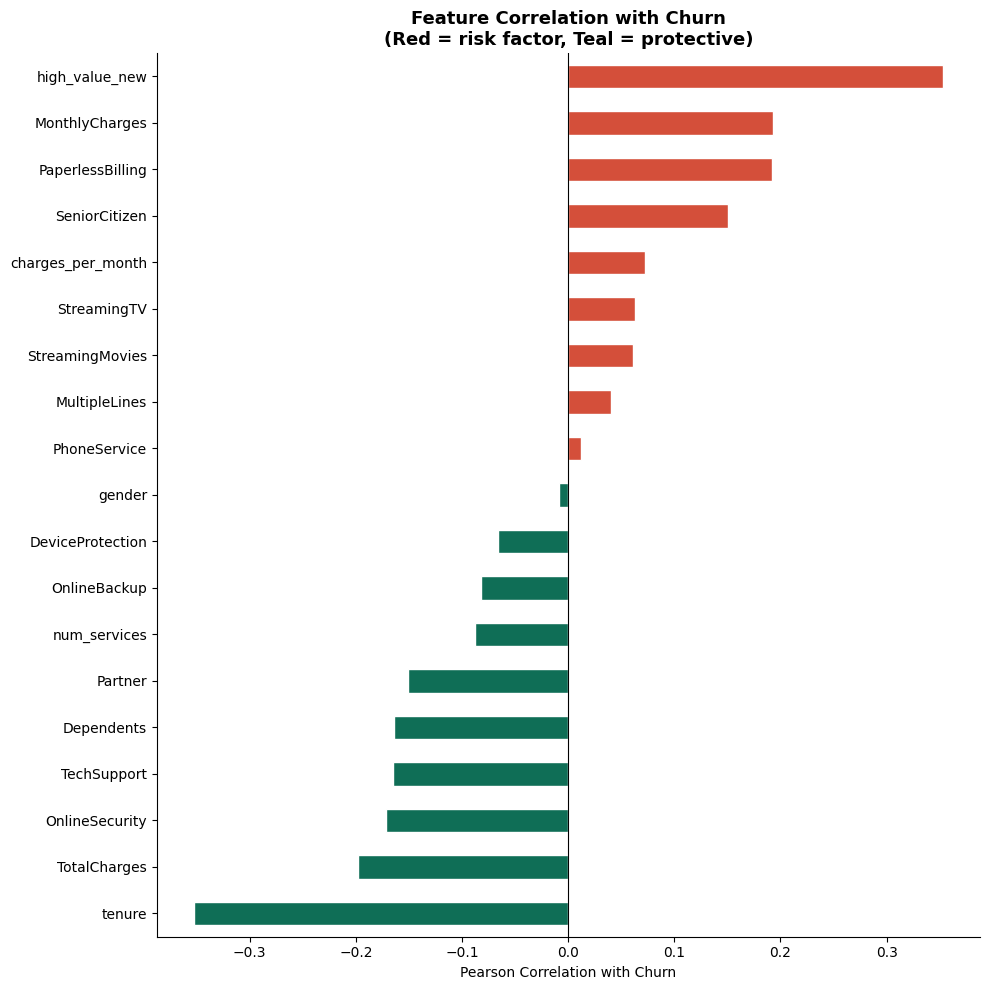

Saved: 05_feature_correlations.png

Top 5 positive correlations with Churn:
charges_per_month    0.073
SeniorCitizen        0.151
PaperlessBilling     0.192
MonthlyCharges       0.193
high_value_new       0.353

Top 5 negative (protective) correlations:
tenure           -0.352
TotalCharges     -0.198
OnlineSecurity   -0.171
TechSupport      -0.165
Dependents       -0.164


In [13]:
corr_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()
correlations = df_model[corr_cols].corr()['Churn_binary'].drop('Churn_binary').sort_values()
colors_corr = [CORAL if x > 0 else TEAL for x in correlations]
fig, ax = plt.subplots(figsize=(10, 10))
correlations.plot(kind='barh', color=colors_corr, ax=ax, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Churn\n(Red = risk factor, Teal = protective)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson Correlation with Churn')
plt.tight_layout()
plt.savefig('../outputs/05_feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 05_feature_correlations.png")

print(f"\nTop 5 positive correlations with Churn:")
print(correlations.tail(5).round(3).to_string())
print(f"\nTop 5 negative (protective) correlations:")
print(correlations.head(5).round(3).to_string())


**Interpretation**: `tenure` is the strongest **protective** feature (negative correlation) — longer customers are more loyal. `Contract_Month-to-month` is the strongest **risk** factor. `num_services` is strongly protective — more services = higher switching cost = less churn. These confirm our 3 engineered features capture real signal.

## EDA Summary — Key Decisions for Modelling

| EDA Finding | Modelling Decision |
|---|---|
| 73/27 class imbalance | Use **F2 score** and **Expected Value** as primary metrics, not accuracy |
| Churn rate drops sharply after month 12 | Engineer `high_value_new` flag; run stratified analysis in NB07 |
| Month-to-month contract has 14× higher churn than two-year | Contract type must be in the model; one-hot encode with `drop_first=True` |
| Fiber optic ~42% churn vs DSL ~19% | `InternetService` is a strong predictor; include as one-hot feature |
| Electronic check payment ~45% churn | Include `PaymentMethod` as one-hot feature |
| `tenure` is the single strongest protective feature (correlation = -0.35) | Do not remove tenure; it anchors the model's risk score |
| `num_services` negatively correlated with churn | Engineered feature validated — retain in all models |
| `charges_per_month` more informative than raw `TotalCharges` | Include both; GridSearchCV will naturally down-weight the less useful one |

**Next step → Notebook 02**: Apply this encoding, engineer features, and produce train/test splits for modelling.